In [3]:
import pandas as pd
import numpy as np
import os
from astropy import constants
from astropy import units as u
from matplotlib import pyplot as plt
from pyTNG.cosmology import TNGcosmo

In [494]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

In [495]:
def update_df(df):
    
    unit_dict = {}
    
    # Temporary, to be updated later
    df['Redshift'] = 6.0107573988449
    
    # Level 1
    h = 0.6774
    df['Volume'] = df['Volume']*h**3/(df['Redshift']+1)**3
    df['Radius_x_sqrt_height'] = (df['Volume']/np.pi)**0.5
    df['Gas_surface_dens_/_height'] = 1e10*df['GasMass']/(h*np.pi*df['Radius_x_sqrt_height']**2)
    df['Star_surface_dens_/_height'] = 1e10*df['StarMass']/(h*np.pi*df['Radius_x_sqrt_height']**2)
    df['Sfr_surface_dens_/_height'] = df['SFR']/(np.pi*df['Radius_x_sqrt_height']**2)
    df['Ionizing_flux_/_height'] = df['ion_lum']/(np.pi*df['Radius_x_sqrt_height']**2)
    
    unit_dict['ion_lum'] = u.s**(-1)
    unit_dict['luminosity'] = u.Lsun
    unit_dict['Radius_x_sqrt_height'] = u.kpc**(3/2)
    unit_dict['Gas_surface_dens_/_height'] = u.Msun/u.kpc**3
    unit_dict['Star_surface_dens_/_height'] = u.Msun/u.kpc**3
    unit_dict['Sfr_surface_dens_/_height'] = u.Msun/u.kpc**3/u.yr
    unit_dict['Ionizing_flux_/_height'] = u.kpc**(-3)*u.s**(-1)
    
    # Level 2
    Z_solar = 0.0134
    df['Dust_normalized'] = df['Z']/Z_solar
    df['Gas_fraction'] = df['GasMass']/(df['GasMass']+df['StarMass'])
    # df['Galaxy_rotation_frequency'] = 0.41*(1+df['redshift'])**(2/3)
    df['Bolometric_flux_/_height'] = df['luminosity']/(np.pi*df['Radius_x_sqrt_height']**2)
    
    unit_dict['Bolometric_flux_/_height'] = unit_dict['luminosity']/(unit_dict['Radius_x_sqrt_height']**2)
    
    # Level 3
    # df['Velocity_dispersion_/_height'] = df['Sfr_surface_dens_/_height']/(df['Gas_fraction']*df['Galaxy_rotation_frequency'])**2
    df['Critical_column_dens'] = 4.3e20/df['Dust_normalized']
    df['Gravitational_pressure_/_height_sq'] = np.pi/2*constants.G.value*df['Gas_surface_dens_/_height']**2/df['Gas_fraction']
    df['Dust_cross_per_H'] = 4.8e-22*df['Dust_normalized']
    
    # unit_dict['Velocity_dispersion_/_height'] = u.km/u.s/u.kpc
    unit_dict['Critical_column_dens'] = u.cm**(-2)
    unit_dict['Gravitational_pressure_/_height_sq'] = constants.G.unit*unit_dict['Gas_surface_dens_/_height']**2
    unit_dict['Dust_cross_per_H'] = u.cm**2
    
    # Level 4
    # df['Column_height_/_height'] = df['Velocity_dispersion_/_height']**2/(np.pi*constants.G.value*(df['Gas_surface_dens_/_height']+df['Star_surface_dens_/_height']))
    
    # unit_dict['Column_height_/_height'] = unit_dict['Velocity_dispersion_/_height']**2/(constants.G.unit*unit_dict['Gas_surface_dens_/_height'])
    
    # Level 5
    mu = 1 #Mean molecular weight to be adjusted later
    df['Particle_dens'] = df['Gas_surface_dens_/_height']/(mu*constants.m_p.value)
    
    unit_dict['Particle_dens'] = unit_dict['Gas_surface_dens_/_height']/(constants.m_p.unit)
    
    # Level 6
    unit_corr_photon_to_gas = float(1*unit_dict['Ionizing_flux_/_height']*u.kpc/(unit_dict['Particle_dens']*constants.c.unit))
    
    df['Photon_to_gas_/_height'] = df['Ionizing_flux_/_height']/(df['Particle_dens']*constants.c.value)*unit_corr_photon_to_gas
    df['Gas_column_dens_/_height'] = df['Particle_dens']
    
    unit_dict['Gas_column_dens_/_height'] = unit_dict['Particle_dens']
    
    # Level 7
    unit_corr_optical_depth = float(1*unit_dict['Dust_cross_per_H']*unit_dict['Gas_column_dens_/_height']*u.kpc)
    
    case_B_param = 2.6e-13*u.cm**3/u.s
    df['U1_/_height'] = df['Gas_fraction']**3*df['Photon_to_gas_/_height']
    df['Column_dens_stroemgren'] = df['Gas_fraction']*constants.c.value/case_B_param.value
    df['Optical_depth_/_height'] = df['Dust_cross_per_H']*df['Gas_column_dens_/_height']*unit_corr_optical_depth
    
    unit_dict['Column_dens_stroemgren'] = constants.c.unit/case_B_param.unit

    # Level 8 
    N_ratio_corr = float(1*unit_dict['Gas_column_dens_/_height']*u.kpc/unit_dict['Critical_column_dens'])
    
    df['Radiation_pressure_/_height_prefactor'] = df['Bolometric_flux_/_height']/constants.c.value
    df['N_ratio_/_height'] = df['Gas_column_dens_/_height']/df['Critical_column_dens']*N_ratio_corr
    
    unit_dict['Radiation_pressure_/_height_prefactor'] = unit_dict['Bolometric_flux_/_height']/constants.c.unit

    # Level 9
    unit_corr_rad_pressure = (unit_dict['Radiation_pressure_/_height_prefactor']*u.kpc).to(u.Pa)
    unit_corr_grav_pressure = (unit_dict['Gravitational_pressure_/_height_sq']*u.kpc**2).to(u.Pa)

    df['Radiation_pressure_/_height_prefactor'] = df['Radiation_pressure_/_height_prefactor']*unit_corr_rad_pressure
    df['Gravitational_pressure_/_height_sq'] = df['Gravitational_pressure_/_height_sq']*unit_corr_grav_pressure

    unit_dict['Radiation_pressure_/_height_prefactor'] = u.Pa
    unit_dict['Gravitational_pressure_/_height_sq'] = u.Pa
    
    return unit_dict

In [496]:
def prefactor(df, height):
    return (1-np.exp(-1*df['Optical_depth_/_height']*height))

In [497]:
def outflow_velocity(element):
    return (2*element['Column_height']*(element['Radiation_pressure']-element['Gravitational_pressure'])/(element['Gas_surface_dens']))**0.5

In [498]:
def escape_fraction(element):
    return np.exp(-element['Reduced_column_dens']*(1/element['Column_dens_stroemgren']+1/element['Critical_column_dens']))   

Function calculating the escape fraction for a dataframe, height of the slate must be given in kpc

In [499]:
def fesc(df, height, unit_dict):
    prefactors = prefactor(df, height)
    df['Radiation_pressure'] = df['Radiation_pressure_/_height_prefactor']*height*prefactors
    df['Gravitational_pressure'] = df['Gravitational_pressure_/_height_sq']*height**2
    df['Column_height'] = height
    df['Gas_surface_dens'] = df['Gas_surface_dens_/_height']*height
    df['Outflow_velocity'] = df.apply(lambda x: 0 if x['Radiation_pressure']<x['Gravitational_pressure'] else outflow_velocity(x), axis=1)
    df['Critical_gas_fraction'] = 6*(df['Dust_normalized']*df['U1_/_height']*height*((1-df['N_ratio_/_height']*height)/(df['N_ratio_/_height']*height)))**(1/3)
    
    
    unit_dict['Radiation_pressure'] = u.Pa
    unit_dict['Gravitational_pressure'] = u.Pa
    unit_dict['Gas_surface_dens'] = unit_dict['Gas_surface_dens_/_height']*u.kpc
    unit_dict['Column_height'] = u.kpc
    unit_dict['Outflow_velocity'] = (unit_dict['Column_height']*unit_dict['Radiation_pressure']/unit_dict['Gas_surface_dens'])**0.5
    
    t_OB = 2*u.Myr
    w_corr = float(1*unit_dict['Outflow_velocity']*u.Myr/unit_dict['Column_height'])
    df['w'] = 0.5*df['Outflow_velocity']*t_OB.value/(df['Column_height'])*w_corr
    df['w'] = df.apply(lambda x: x['w'] if x['w']<1 else 1, axis=1)
    df['Reduced_column_dens'] = (1-df['w'])*df['Gas_column_dens_/_height']*height

    unit_dict['Reduced_column_dens'] = unit_dict['Gas_column_dens_/_height']*u.kpc
    
    unit_corr_reduced_colum_dens = unit_dict['Reduced_column_dens'].to(u.cm**(-2))
    unit_corr_column_dens_stroemgren = unit_dict['Column_dens_stroemgren'].to(u.cm**(-2))
    unit_corr_crit_column_dens = unit_dict['Critical_column_dens'].to(u.cm**(-2))

    unit_dict['Reduced_column_dens'] = u.cm**(-2)
    unit_dict['Column_dens_stroemgren'] = u.cm**(-2)
    unit_dict['Critical_column_dens'] = u.cm**(-2)
    
    df['Reduced_column_dens'] = df['Reduced_column_dens']*unit_corr_reduced_colum_dens
    df['Column_dens_stroemgren'] = df['Column_dens_stroemgren']*unit_corr_column_dens_stroemgren
    df['Column_dens_stroemgren'] = df['Column_dens_stroemgren']*unit_corr_crit_column_dens
    
    df['fesc'] = df.apply(lambda x: 0 if x['Gas_fraction']<x['Critical_gas_fraction'] else escape_fraction(x), axis=1)
    
    return

In [491]:
path = '/ptmp/mpa/ivkos/semianalytic_fesc/df_snap013_lv0.pickle'
df = pd.read_pickle(path)

In [492]:
df

,HaloMass,GasMass,StarMass,SFR,com_radius,Z,ion_lum,luminosity,Volume,radius,gas_surface_dens,star_surface_dens,sfr_surface_dens,ionizing_flux,redshift
0,3.268400,0.046631,1.466784,391.632751,1.191221,0.024224,5.381087e+55,2.827028e+12,4.886648,12.328552,1.441620e+06,4.534683e+07,8.201720e-01,1.126927e+53,6.010757
1,0.796984,0.105127,0.007640,1.798865,17.856184,0.002935,4.633019e+53,1.581281e+10,7840.357422,184.802737,1.446448e+04,1.051199e+03,1.676610e-05,4.318147e+48,6.010757
2,0.261141,0.024970,0.004407,0.346270,12.280504,0.005254,1.235711e+53,5.073973e+09,2529.611084,127.097189,7.263599e+03,1.282089e+03,6.823269e-06,2.434979e+48,6.010757
3,0.471234,0.019457,0.001432,0.122709,26.634462,0.002896,2.664170e+52,1.109281e+09,4830.437500,275.653608,1.203273e+03,8.854432e+01,5.140416e-07,1.116053e+47,6.010757
4,0.171911,0.011700,0.001957,0.115020,11.067033,0.005981,1.658566e+52,1.295753e+09,1404.406738,114.538356,4.190846e+03,7.008160e+02,2.790745e-06,4.024212e+47,6.010757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2317355,0.001063,0.000014,0.000002,0.000055,2.165431,0.000619,2.132275e+46,3.877439e+05,6.167997,22.411143,1.269006e+02,2.256657e+01,3.508738e-08,1.351342e+43,6.010757
2329332,0.001077,0.000005,0.000002,0.000020,2.109513,0.000909,4.984457e+47,7.994795e+05,2.204074,21.832424,4.781800e+01,2.384236e+01,1.322595e-08,3.328619e+44,6.010757
2351454,0.002203,0.000010,0.000003,0.000042,3.708047,0.000340,1.068024e+47,6.511045e+05,4.690549,38.376462,3.290817e+01,9.521682e+00,9.098566e-09,2.308348e+43,6.010757
2368557,0.001249,0.000004,0.000004,0.000017,2.587251,0.000618,2.087529e+47,9.405464e+05,1.933473,26.776775,2.787013e+01,2.622845e+01,7.706527e-09,9.267575e+43,6.010757


In [487]:
unit_dict = update_df(df)

In [488]:
height = df['Volume']**(1/3)/100
fesc(df, height=height, unit_dict=unit_dict)

In [421]:
col_norm = colors.DivergingNorm(vmin=v_min, vcenter=v_center, vmax=v_max)
df_plot = df[df['Gas_fraction']>0.8]
df_plot = df_plot[np.log10(df_plot['Sfr_surface_dens_/_height']*height)<-6]
x_values = df_plot['Gas_fraction']
y_valyes = np.log10(np.log10(df_plot['Sfr_surface_dens_/_height']*height))
hist, xedges, yedges, binnumber = stats.binned_statistic_2d(np.log10(x_values), f_esc, values = color_data, statistic=filter_function , bins = [bins[0], bins[1]], range=[[6,8],[0,1]])
hist_cont, xedges_cont, yedges_cont, binnumber_cont = stats.binned_statistic_2d(np.log10(x_values), f_esc, values = color_data, statistic='count', 
                                                                                bins = [bins[0], bins[1]], range=[[6,8],[0,1]])
levels = get_levels(hist_cont, thresholds=[0.954, 0.683])
x_grid, y_grid = np.meshgrid(xedges, yedges)
cont_centers_x = (xedges_cont[1:]+xedges_cont[:-1])/2
cont_centers_y = (yedges_cont[1:]+yedges_cont[:-1])/2

x_grid_cont, y_grid_cont = np.meshgrid(cont_centers_x, cont_centers_y)
subfig = ax.pcolormesh(x_grid, y_grid, hist.T,norm=col_norm, cmap=plt.get_cmap('coolwarm'))

NameError: name 'colors' is not defined

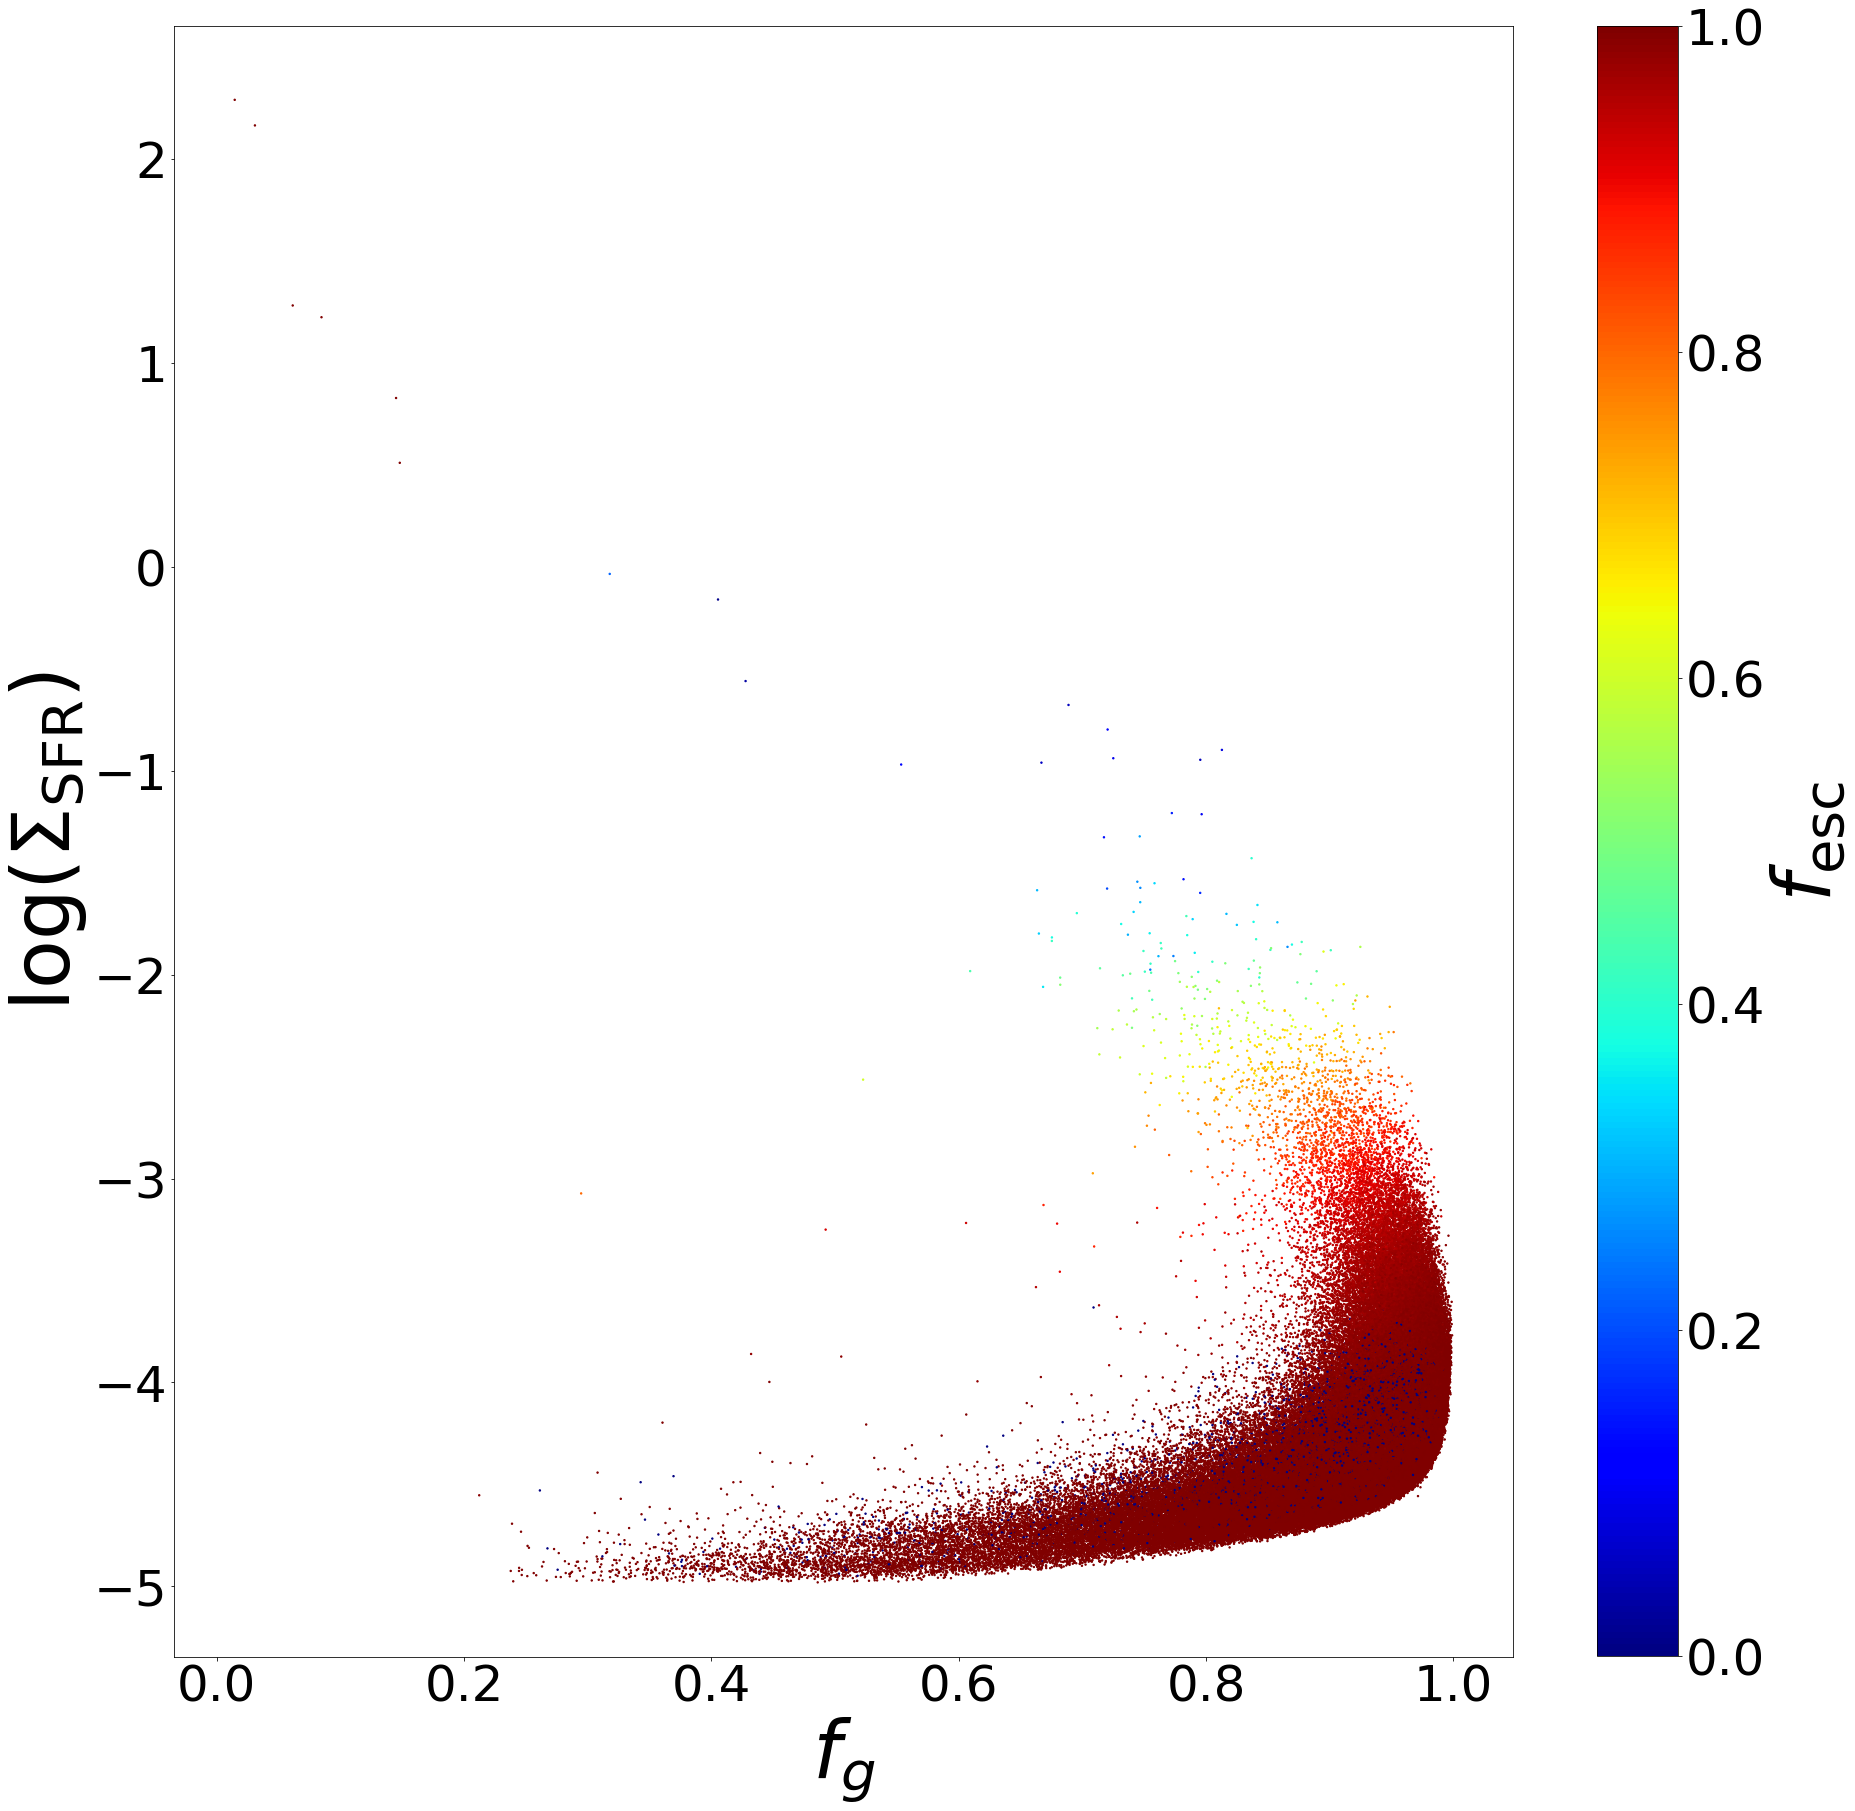

In [489]:
labelsize = 80
ticksize = 50 
plt.rcParams['figure.figsize'] = [30, 30]
plt.rc('xtick', labelsize=ticksize) 
plt.rc('ytick', labelsize=ticksize) 
plt.scatter(df['Gas_fraction'], np.log10(df['Sfr_surface_dens_/_height']*height), s=2, c=df['fesc'], cmap='jet')
plt.xlabel('$f_g$', size=labelsize)
plt.ylabel('$\log(\Sigma_\mathrm{SFR})$', size=labelsize)
cbar = plt.colorbar()
cbar.set_label(r'$f_\mathrm{esc}$', size=labelsize)
#plt.xlim(0.8, 1.0)
#plt.ylim(-7, -6)